# Image Processing Tutorial with OpenCV

This notebook demonstrates various image processing techniques using OpenCV and NumPy. We'll explore filtering, morphological operations, geometric transformations, and more, applied to a sample image.

## Requirements

- OpenCV
- NumPy
- Matplotlib

## 1. Loading Image and Applying Basic Filters

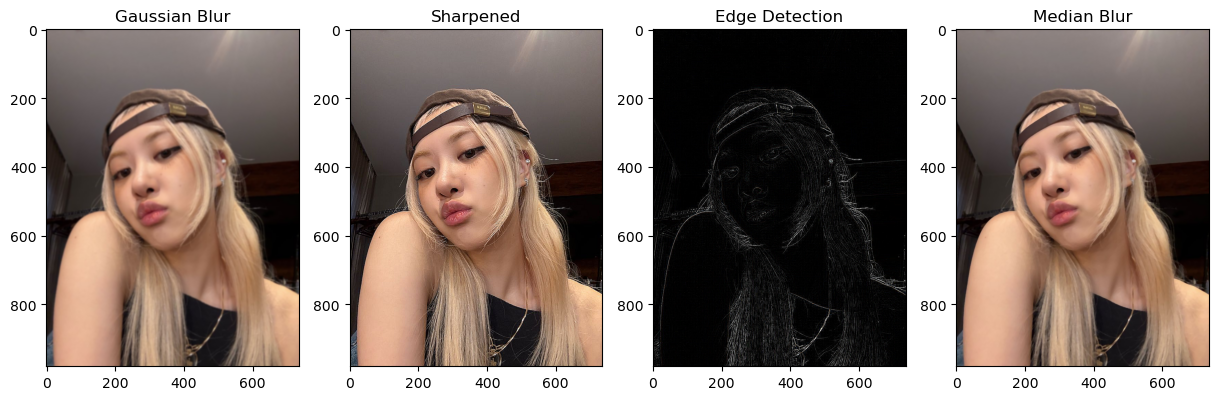

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r"C:\Github\DSP\New folder\Rose Selfie.jpg")

# Gaussian Blur
gaussian = cv2.GaussianBlur(img, (9,9), 0)

# Sharpening kernel
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
sharpen = cv2.filter2D(img, -1, kernel_sharpen)

# Edge Detection kernel
kernel_edge = np.array([[-1,-1,-1],
                        [-1,8,-1],
                        [-1,-1,-1]])
edge = cv2.filter2D(img, -1, kernel_edge)

# Median Blur
median = cv2.medianBlur(img, 5)

# Save outputs
cv2.imwrite("Gaussian.jpg", gaussian)
cv2.imwrite("Sharpen.jpg", sharpen)
cv2.imwrite("Edge.jpg", edge)
cv2.imwrite("Median.jpg", median)

# Display outputs
plt.figure(figsize=(15,5))
plt.subplot(1,4,1), plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)), plt.title('Gaussian Blur')
plt.subplot(1,4,2), plt.imshow(cv2.cvtColor(sharpen, cv2.COLOR_BGR2RGB)), plt.title('Sharpened')
plt.subplot(1,4,3), plt.imshow(cv2.cvtColor(edge, cv2.COLOR_BGR2RGB)), plt.title('Edge Detection')
plt.subplot(1,4,4), plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB)), plt.title('Median Blur')
plt.show()

## 2. Converting to Grayscale

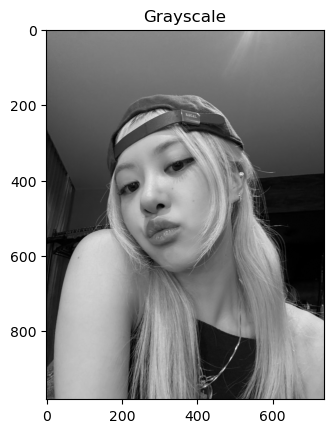

In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imwrite("selfie_gray.jpg", gray)

# Display
plt.imshow(gray, cmap='gray'), plt.title('Grayscale')
plt.show()

## 3. Morphological Operations: Erosion and Dilation

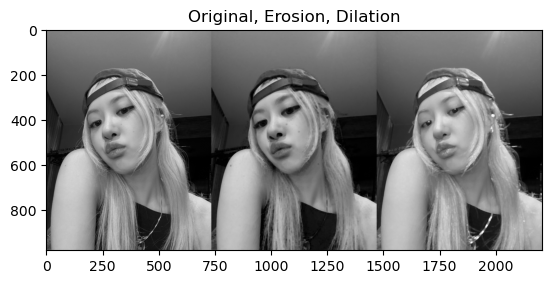

In [3]:
kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(gray, kernel, iterations=1)
dilation = cv2.dilate(gray, kernel, iterations=1)

combined1 = np.hstack((gray, erosion, dilation))
cv2.imwrite("Erosion_Dilation_Comparison.jpg", combined1)

# Display
plt.imshow(combined1, cmap='gray'), plt.title('Original, Erosion, Dilation')
plt.show()

## 4. Adding Noise to the Image

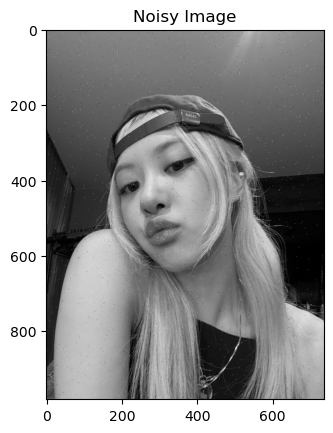

In [4]:
noisy = gray.copy()
num_pixels = 1000

for i in range(num_pixels):
    x = np.random.randint(0, noisy.shape[0])
    y = np.random.randint(0, noisy.shape[1])
    noisy[x,y] = 255

for i in range(num_pixels):
    x = np.random.randint(0, noisy.shape[0])
    y = np.random.randint(0, noisy.shape[1])
    noisy[x,y] = 0

# Display
plt.imshow(noisy, cmap='gray'), plt.title('Noisy Image')
plt.show()

## 5. Morphological Operations: Opening and Closing

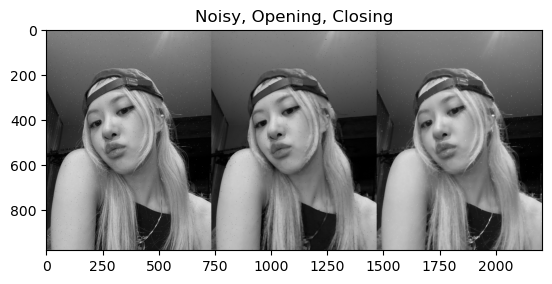

In [5]:
opening = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(noisy, cv2.MORPH_CLOSE, kernel)

combined2 = np.hstack((noisy, opening, closing))
cv2.imwrite("Opening_Closing_Comparison.jpg", combined2)

# Display
plt.imshow(combined2, cmap='gray'), plt.title('Noisy, Opening, Closing')
plt.show()

## 6. Rotation and Scaling

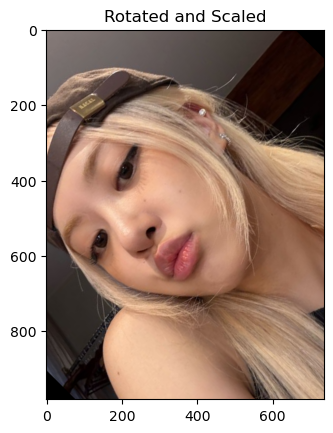

In [6]:
(h, w) = img.shape[:2]
center = (w//2, h//2)

matrix = cv2.getRotationMatrix2D(center, 45, 1.5)
rotated_scaled = cv2.warpAffine(img, matrix, (w, h))

cv2.imwrite("Rotated_Scaled.jpg", rotated_scaled)

# Display
plt.imshow(cv2.cvtColor(rotated_scaled, cv2.COLOR_BGR2RGB)), plt.title('Rotated and Scaled')
plt.show()

## 7. Resizing and Inversion

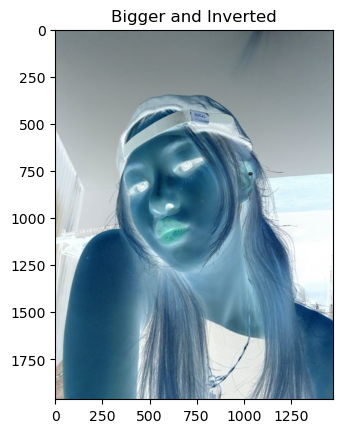

In [7]:
bigger = cv2.resize(img, None, fx=2, fy=2)
inverted = cv2.bitwise_not(bigger)

cv2.imwrite("Bigger_Inverted.jpg", inverted)

# Display
plt.imshow(cv2.cvtColor(inverted, cv2.COLOR_BGR2RGB)), plt.title('Bigger and Inverted')
plt.show()

## 8. Interpolation Methods

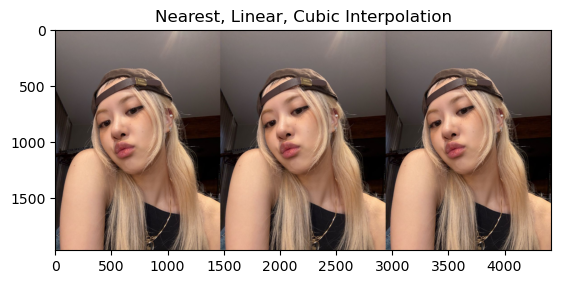

In [8]:
nearest = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)
linear = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
cubic = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

combined3 = np.hstack((nearest, linear, cubic))
cv2.imwrite("Interpolation_Comparison.jpg", combined3)

# Display
plt.imshow(cv2.cvtColor(combined3, cv2.COLOR_BGR2RGB)), plt.title('Nearest, Linear, Cubic Interpolation')
plt.show()

## 9. Affine Transformations

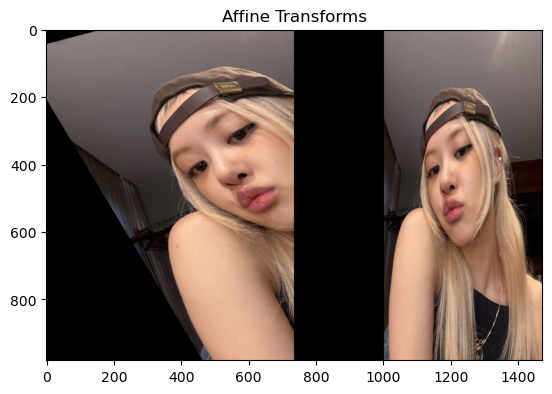

In [9]:
rows, cols, ch = img.shape

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

pts3 = np.float32([[50,50],[200,50],[50,200]])
pts4 = np.float32([[300,50],[400,50],[300,200]])

matrix1 = cv2.getAffineTransform(pts1, pts2)
matrix2 = cv2.getAffineTransform(pts3, pts4)

affine1 = cv2.warpAffine(img, matrix1, (cols, rows))
affine2 = cv2.warpAffine(img, matrix2, (cols, rows))

combined4 = np.hstack((affine1, affine2))
cv2.imwrite("Affine_Transform.jpg", combined4)

# Display
plt.imshow(cv2.cvtColor(combined4, cv2.COLOR_BGR2RGB)), plt.title('Affine Transforms')
plt.show()